# M8 DLCV - ASSIGNMENT 2
Semantic Segmentation Using Torchvision

Overview:

In this assignment, you will implement a pre-trained semantic segmentation model to perform pixel-level scene understanding on a high-density urban street image. You will focus on loading the model, preprocessing the image, performing semantic segmentation, and visualizing the segmented regions corresponding to different object classes.

Pre trained model to be Used
* fcn_resnet50
Tasks
1. Load a pre-trained semantic segmentation model using torchvision.
2. Preprocess and transform the input image for segmentation.
3. Perform semantic segmentation and identify object regions in the image.
4. Visualize and analyze the segmented output generated by the model.

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch
import torchvision.transforms as T
from torchvision import models
from PIL import Image, ImageOps
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

## Task 1: Load Pre-trained Segmentation Model

FCN-ResNet50 is a Fully Convolutional Network trained on the COCO dataset using PASCAL VOC classes.
It classifies each pixel into one of 21 categories (background + 20 object classes).

In [2]:
def load_model():
    model = models.segmentation.fcn_resnet50(weights='DEFAULT')
    model.eval()
    return model

model = load_model()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print('Model loaded on:', device)

Model loaded on: cpu


## Task 2: Preprocess and Transform the Input Image

The model expects a normalized tensor with ImageNet mean and standard deviation.
The image is resized so its shorter side is 520 pixels before normalization.

Image size: 1536x1024 px
Image mode: RGB


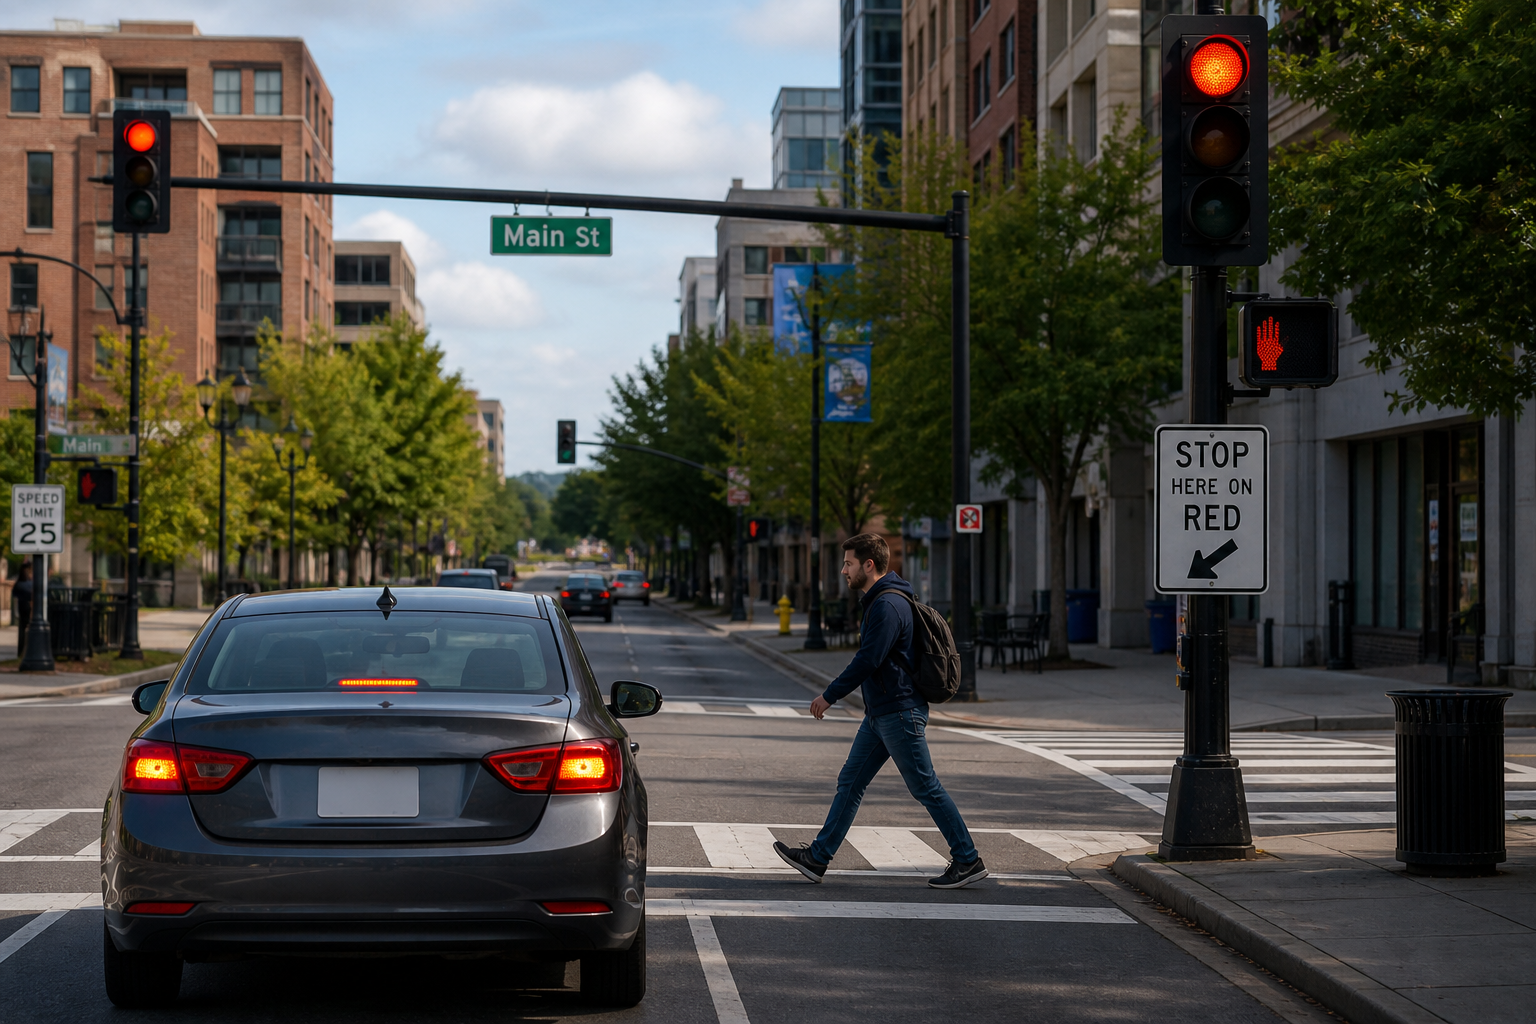

In [3]:
def load_image(path):
    image = Image.open(path).convert('RGB')
    image = ImageOps.exif_transpose(image)
    return image

def preprocess_image(image):
    preprocess = T.Compose([
        T.Resize(520),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    return preprocess(image).unsqueeze(0)

image_path = '../../classes/m8/ViT Image.png'
image = load_image(image_path)

print(f'Image size: {image.size[0]}x{image.size[1]} px')
print(f'Image mode: {image.mode}')
display(image)

## Task 3: Perform Semantic Segmentation

The model outputs a score map of shape `[21, H, W]` — one channel per class.
`argmax` over the class dimension assigns each pixel its most likely class label.

In [4]:
def segment_image(model, image, device):
    input_tensor = preprocess_image(image).to(device)
    with torch.no_grad():
        output = model(input_tensor)['out'][0]
    predictions = output.argmax(0).cpu().numpy()
    return predictions

predictions = segment_image(model, image, device)

print(f'Prediction map shape: {predictions.shape}')
print(f'Unique class IDs found: {np.unique(predictions)}')

Prediction map shape: (520, 780)
Unique class IDs found: [ 0  7 15]


## Task 4: Visualize and Analyze the Segmented Output

Each PASCAL VOC class is assigned a unique color. The segmentation map is decoded into
an RGB image and displayed alongside the original for comparison.

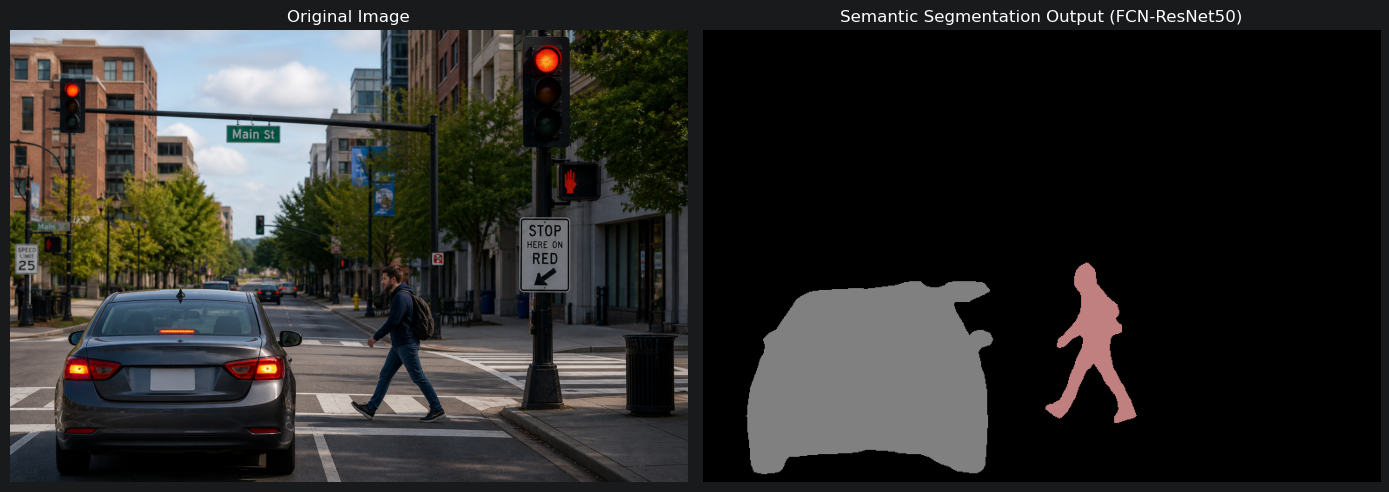

In [5]:
# PASCAL VOC classes used by FCN-ResNet50 (trained on COCO with VOC labels)
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog',
    'horse', 'motorbike', 'person', 'pottedplant', 'sheep',
    'sofa', 'train', 'tvmonitor'
]

LABEL_COLORS = np.array([
    (0,   0,   0),    # background
    (128, 0,   0),    # aeroplane
    (0,   128, 0),    # bicycle
    (128, 128, 0),    # bird
    (0,   0,   128),  # boat
    (128, 0,   128),  # bottle
    (0,   128, 128),  # bus
    (128, 128, 128),  # car
    (64,  0,   0),    # cat
    (192, 0,   0),    # chair
    (64,  128, 0),    # cow
    (192, 128, 0),    # diningtable
    (64,  0,   128),  # dog
    (192, 0,   128),  # horse
    (64,  128, 128),  # motorbike
    (192, 128, 128),  # person
    (0,   64,  0),    # pottedplant
    (128, 64,  0),    # sheep
    (0,   192, 0),    # sofa
    (128, 192, 0),    # train
    (0,   64,  128),  # tvmonitor
])

def decode_segmap(predictions):
    h, w = predictions.shape
    color_image = np.zeros((h, w, 3), dtype=np.uint8)
    for label in range(len(LABEL_COLORS)):
        color_image[predictions == label] = LABEL_COLORS[label]
    return color_image

seg_image = decode_segmap(predictions)

# Side-by-side comparison
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(seg_image)
plt.title('Semantic Segmentation Output (FCN-ResNet50)')
plt.axis('off')

plt.tight_layout()
plt.show()

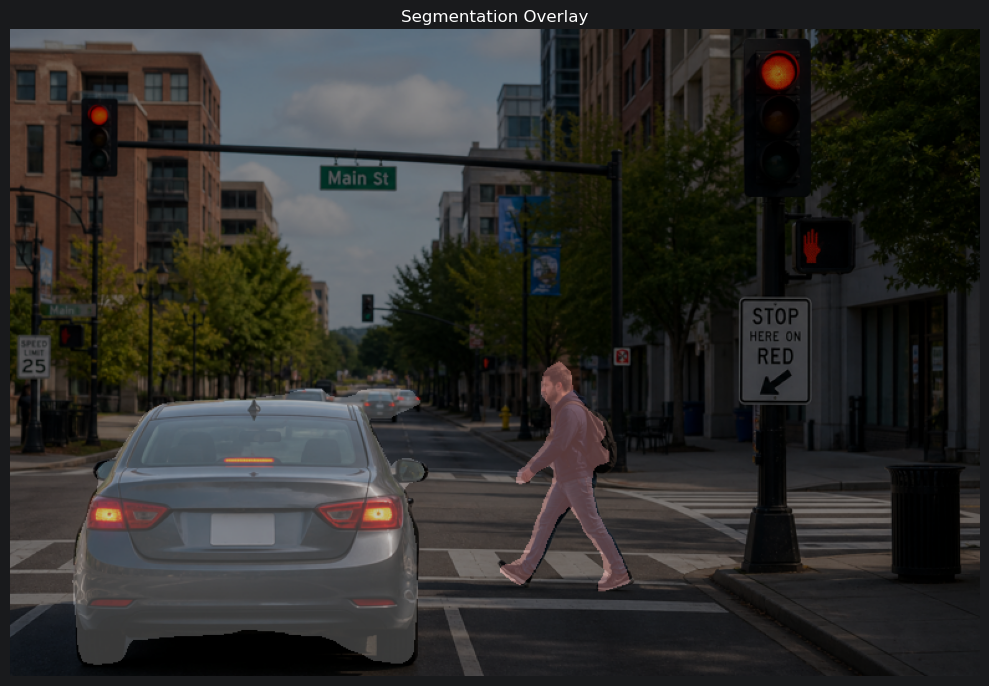

In [6]:
# Blended overlay: original image + segmentation mask
original_resized = np.array(image.resize((seg_image.shape[1], seg_image.shape[0])))
overlay = (0.55 * original_resized + 0.45 * seg_image).astype(np.uint8)

plt.figure(figsize=(10, 7))
plt.imshow(overlay)
plt.title('Segmentation Overlay')
plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Pixel coverage analysis — which classes are present and how much of the image they occupy
total_pixels = predictions.size
detected_classes = np.unique(predictions)

records = []
for cls_id in detected_classes:
    pixel_count = int(np.sum(predictions == cls_id))
    pct = pixel_count / total_pixels * 100
    records.append({
        'Class ID': cls_id,
        'Class Name': VOC_CLASSES[cls_id],
        'Pixels': pixel_count,
        'Coverage (%)': round(pct, 2)
    })

df_seg = pd.DataFrame(records).sort_values('Coverage (%)', ascending=False).reset_index(drop=True)
print('Detected classes and pixel coverage:')
print(df_seg.to_string(index=False))

Detected classes and pixel coverage:
 Class ID Class Name  Pixels  Coverage (%)
        0 background  348565         85.94
        7        car   50232         12.38
       15     person    6803          1.68


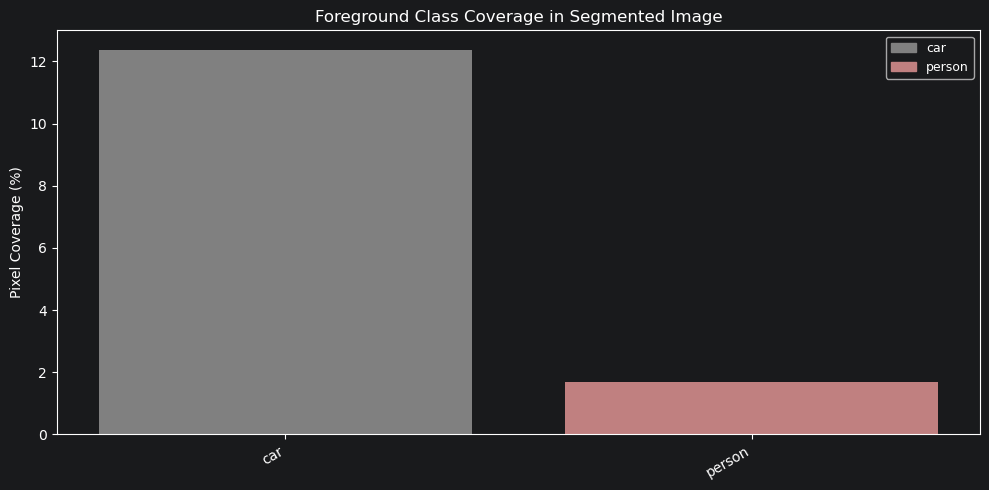

In [8]:
# Bar chart of pixel coverage per detected class (excluding background)
df_fg = df_seg[df_seg['Class Name'] != 'background'].copy()

if df_fg.empty:
    print('Only background detected — no foreground classes found.')
else:
    bar_colors = [
        tuple(c / 255 for c in LABEL_COLORS[row['Class ID']])
        for _, row in df_fg.iterrows()
    ]

    # Legend patches
    legend_patches = [
        mpatches.Patch(color=bar_colors[i], label=df_fg.iloc[i]['Class Name'])
        for i in range(len(df_fg))
    ]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(df_fg['Class Name'], df_fg['Coverage (%)'], color=bar_colors)
    plt.ylabel('Pixel Coverage (%)')
    plt.title('Foreground Class Coverage in Segmented Image')
    plt.xticks(rotation=30, ha='right')
    plt.legend(handles=legend_patches, loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

## Conclusion

The FCN-ResNet50 model performed pixel-level classification of the urban scene image using
the 21 PASCAL VOC class vocabulary.

Key observations:
* Unlike YOLO bounding boxes from Assignment 1, semantic segmentation assigns a class label
  to **every pixel**, capturing the precise shape and boundary of each region.
* The pixel coverage analysis quantifies how much of the scene each class occupies,
  providing a richer spatial understanding beyond simple object counts.
* The overlay visualization confirms that the segmented regions align well with the
  corresponding areas in the original image.
* FCN-ResNet50 is a strong baseline for semantic segmentation; more modern architectures
  such as DeepLab or SegFormer can further improve boundary precision and class accuracy.